# 2.2 — Vector arithmetic, at the computer

Worksheet first, as always. Here you'll *watch* tip-to-tail addition agree with
component addition, then do the famous `king − man + woman` with your own hands.

In [1]:
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import axes_through_origin

def arrow(ax, v, color="C0", label=None, start=(0, 0)):
    ax.quiver(start[0], start[1], v[0], v[1], angles="xy", scale_units="xy",
              scale=1, color=color, width=0.012)
    if label:
        ax.annotate(label, (start[0] + v[0], start[1] + v[1]),
                    textcoords="offset points", xytext=(6, 6), color=color, fontsize=12)

## 1. Two pictures, one answer

$\begin{pmatrix}3\\1\end{pmatrix} + \begin{pmatrix}1\\2\end{pmatrix}$: numpy adds components;
the plot walks tip-to-tail. They *must* land on the same spot — check they do.

a + b = [4 3]    (components added pairwise)


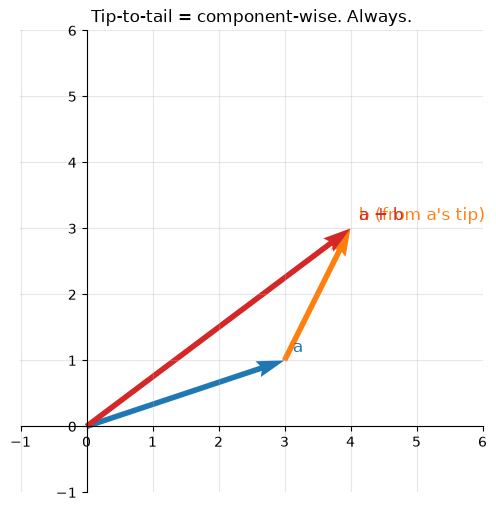

In [2]:
a = np.array([3, 1])
b = np.array([1, 2])
print("a + b =", a + b, "   (components added pairwise)")

ax = axes_through_origin(xlim=(-1, 6), ylim=(-1, 6))
arrow(ax, a, "C0", "a")
arrow(ax, b, "C1", "b (from a's tip)", start=a)   # start b where a ended: tip-to-tail
arrow(ax, a + b, "C3", "a + b")
ax.set_title("Tip-to-tail = component-wise. Always.")
plt.show()

In [3]:
# The full toolkit, in numpy. No loops — arrays do every component at once.
print("a - b  =", a - b)
print("3 * a  =", 3 * a, "    <- a SCALAR scales every component")
print("-1 * b =", -1 * b, "   <- negative scalar: same line, opposite direction")
print("2*a + 3*b =", 2*a + 3*b, "  <- a 'linear combination' — neural nets live on these")

# YOUR TURN — worksheet Part A, problems 1–4: verify each here.


a - b  = [ 2 -1]
3 * a  = [9 3]     <- a SCALAR scales every component
-1 * b = [-1 -2]    <- negative scalar: same line, opposite direction
2*a + 3*b = [9 8]   <- a 'linear combination' — neural nets live on these


## 2. The algebra of meaning

A toy meaning-space: axis 1 = royalty, axis 2 = gender (0 male → 1 female).
Real embeddings use hundreds of axes *learned from data* — but the arithmetic is identical.

The claim to test: $\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$.

king - man + woman = [9. 1.]
  distance to king    : 1.00
  distance to queen   : 0.00
  distance to man     : 8.06
  distance to woman   : 8.00
  distance to peasant : 9.01


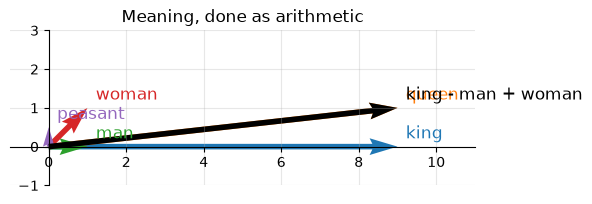

In [4]:
words = {
    "king":  np.array([9.0, 0.0]),
    "queen": np.array([9.0, 1.0]),
    "man":   np.array([1.0, 0.0]),
    "woman": np.array([1.0, 1.0]),
    "peasant": np.array([0.0, 0.5]),
}

result = words["king"] - words["man"] + words["woman"]
print("king - man + woman =", result)

# Which known word is CLOSEST to the result? (Distance between tips — worksheet 2.1 Part D!)
for name, vec in words.items():
    print(f"  distance to {name:8s}: {np.linalg.norm(result - vec):.2f}")

ax = axes_through_origin(xlim=(-1, 11), ylim=(-1, 3))
for i, (name, vec) in enumerate(words.items()):
    arrow(ax, vec, f"C{i}", name)
arrow(ax, result, "k", "king - man + woman")
ax.set_title("Meaning, done as arithmetic")
plt.show()

In [5]:
# YOUR TURN
# 1) Worksheet Part D used a third axis (plural). Rebuild it: give every word above a third
#    component, add kings = [9, 0, 1], and verify  kings - king + woman  lands near "women".
#    (You'll need to invent the vector for "women" — what should its three components be?)

# 2) Invent a NEW axis pair of your own (e.g. axis 1 = 'is a place', axis 2 = 'is food')
#    and build a working analogy like  paris - france + japan.

# 3) Balance-game check (worksheet B, problem 8): solve x + [2,7] = [5,3] on paper moves,
#    then confirm:
# x = np.array([?, ?])
# print(x + np.array([2, 7]) == np.array([5, 3]))   # want [True True]

## 3. 🌀 Why this is astonishing

Nobody *told* word2vec that `king − man + woman = queen`. It read piles of text, placed every
word as an arrow so that words used similarly point similarly — and the analogies **emerged**
from the geometry. Meaning became a place, and directions in that place became concepts:
there is a "royalty direction", a "gender direction", a "plural direction".

You now own both operations that made it possible. Next lesson adds the one that *measures* it.

---
*Photograph your worksheet into `scans/inbox/`. Next: 2.3 — the dot product,
the most important operation in AI. Not hype. Measurably.*